# Medistar Vision — Demonstração de Predição em Imagens Novas

Este notebook demonstra o uso do melhor modelo treinado para classificar novas imagens satelitais.

O modelo recebe um recorte de imagem de satélite e retorna a classe territorial prevista. Essa informação pode apoiar a plataforma Medistar na análise do contexto geográfico de comunidades isoladas, auxiliando a priorização de atendimentos e a avaliação de risco territorial.

In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from keras.models import load_model

In [2]:
MODEL_PATH = Path("../outputs/models/best_model.keras")
TEST_DIR = Path("../data/processed/test")

IMG_SIZE = (128, 128)

class_names = [
    "agricultura",
    "sombra",
    "terreno_exposto",
    "urbano",
    "vegetacao_densa",
    "vegetacao_esparsa"
]

print("Modelo:", MODEL_PATH)
print("Dataset de teste:", TEST_DIR)

Modelo: ..\outputs\models\best_model.keras
Dataset de teste: ..\data\processed\test


In [3]:
model = load_model(MODEL_PATH)

print("Modelo carregado com sucesso.")
model.summary()

Modelo carregado com sucesso.


Model: "cnn_simples_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,546,228 (21.16 MB)

 Trainable params: 1,848,742 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,697,486 (14.10 MB)

In [4]:
medistar_interpretation = {
    "urbano": "Área com maior chance de infraestrutura, acesso terrestre e proximidade de serviços.",
    "vegetacao_densa": "Região com possível isolamento territorial, floresta densa ou acesso mais difícil.",
    "vegetacao_esparsa": "Área rural ou de transição ambiental, podendo indicar ocupação menos densa.",
    "agricultura": "Região rural produtiva, possivelmente afastada de grandes centros urbanos.",
    "terreno_exposto": "Solo aberto, estrada, clareira ou área degradada, podendo indicar acesso precário ou ausência de cobertura vegetal.",
    "sombra": "Área com baixa visibilidade na imagem, podendo dificultar a análise territorial automática."
}

In [5]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize(IMG_SIZE)

    image_array = np.array(image_resized).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    predictions = model.predict(image_array, verbose=0)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    return {
        "image": image,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "all_predictions": predictions
    }

In [6]:
all_test_images = list(TEST_DIR.glob("*/*.png"))

print(f"Total de imagens de teste encontradas: {len(all_test_images)}")

random_image_path = random.choice(all_test_images)

print("Imagem selecionada:")
print(random_image_path)

Total de imagens de teste encontradas: 593
Imagem selecionada:
..\data\processed\test\terreno_exposto\terreno_exposto_raster19_x640_y1408_21.png


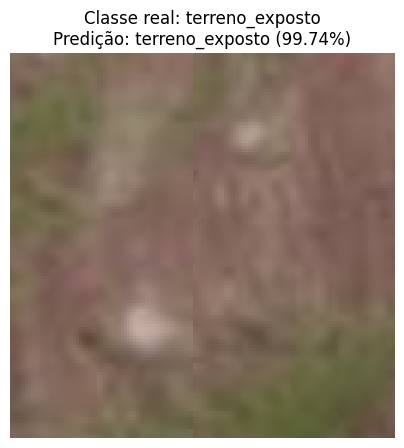

Classe real: terreno_exposto
Classe prevista: terreno_exposto
Confiança: 99.74%

Interpretação Medistar:
Solo aberto, estrada, clareira ou área degradada, podendo indicar acesso precário ou ausência de cobertura vegetal.


In [7]:
result = predict_image(random_image_path)

real_class = random_image_path.parent.name
predicted_class = result["predicted_class"]
confidence = result["confidence"]

plt.figure(figsize=(5, 5))
plt.imshow(result["image"])
plt.axis("off")
plt.title(
    f"Classe real: {real_class}\n"
    f"Predição: {predicted_class} ({confidence:.2%})"
)
plt.show()

print("Classe real:", real_class)
print("Classe prevista:", predicted_class)
print(f"Confiança: {confidence:.2%}")

print("\nInterpretação Medistar:")
print(medistar_interpretation[predicted_class])

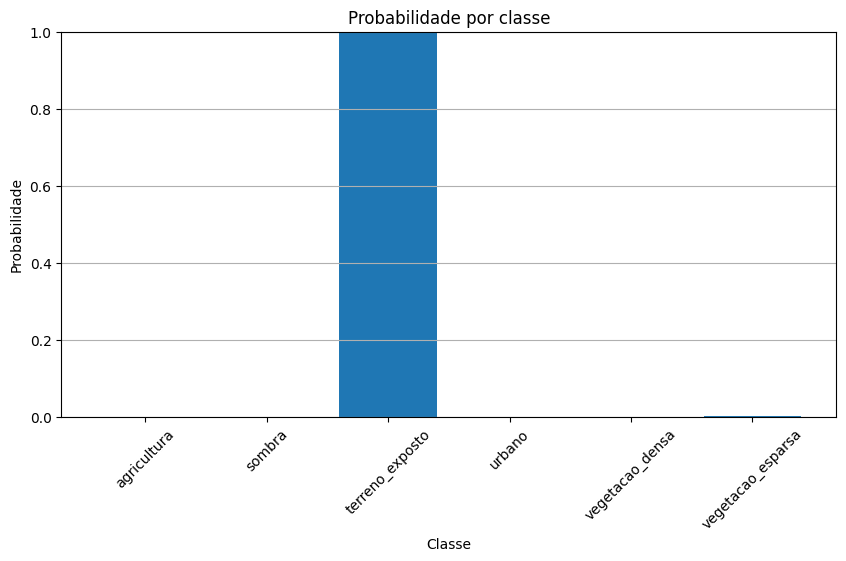

agricultura: 0.01%
sombra: 0.00%
terreno_exposto: 99.74%
urbano: 0.01%
vegetacao_densa: 0.00%
vegetacao_esparsa: 0.24%


In [8]:
predictions = result["all_predictions"]

plt.figure(figsize=(10, 5))
plt.bar(class_names, predictions)
plt.title("Probabilidade por classe")
plt.xlabel("Classe")
plt.ylabel("Probabilidade")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

for class_name, probability in zip(class_names, predictions):
    print(f"{class_name}: {probability:.2%}")

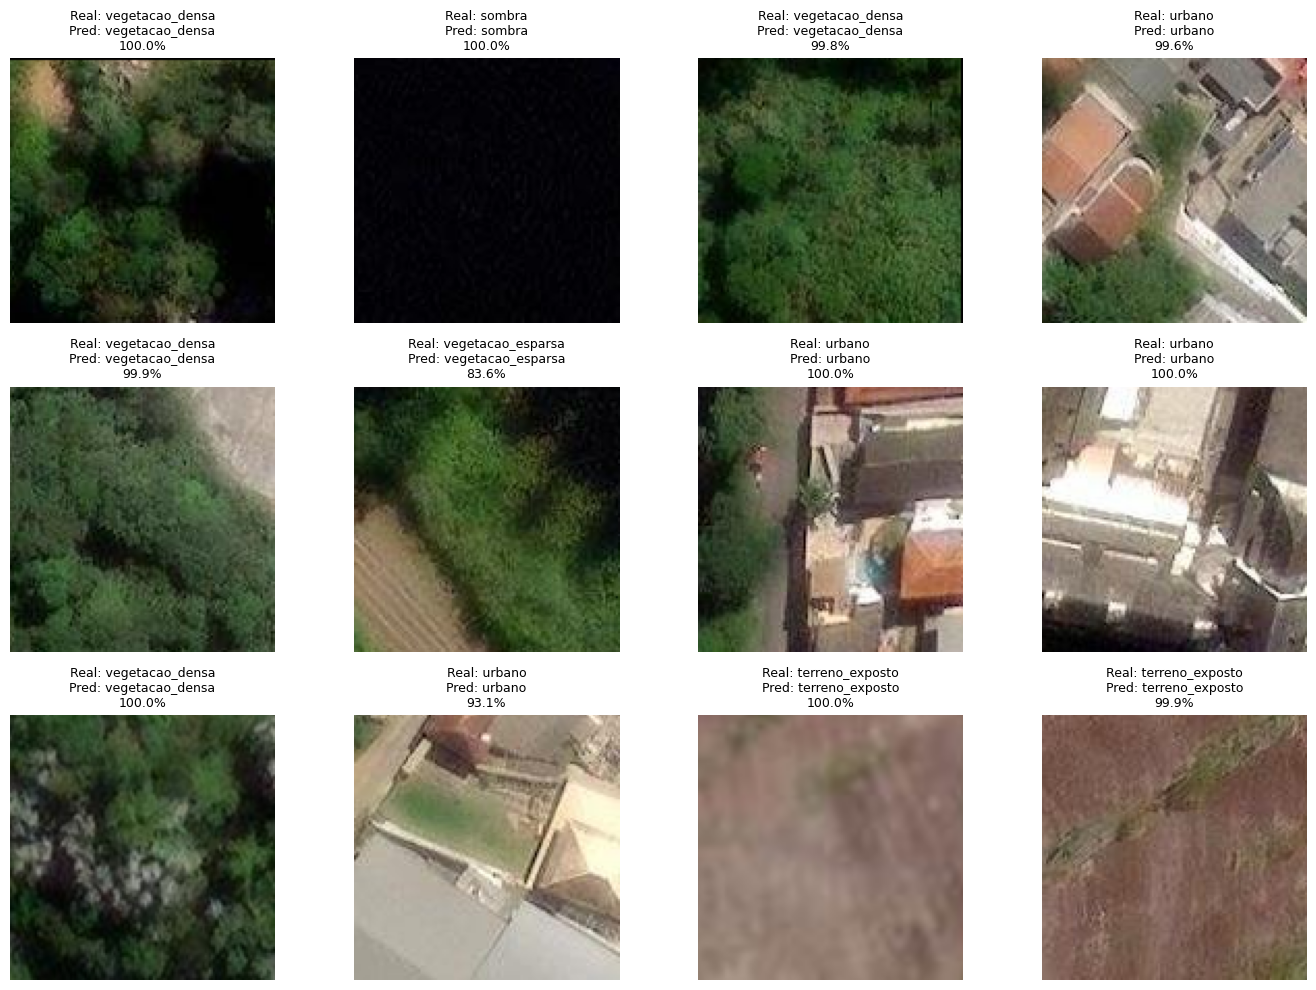

In [9]:
sample_images = random.sample(all_test_images, 12)

plt.figure(figsize=(14, 10))

for i, image_path in enumerate(sample_images):
    result = predict_image(image_path)

    real_class = image_path.parent.name
    predicted_class = result["predicted_class"]
    confidence = result["confidence"]

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(result["image"])
    plt.axis("off")

    title = (
        f"Real: {real_class}\n"
        f"Pred: {predicted_class}\n"
        f"{confidence:.1%}"
    )

    plt.title(title, fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
def medistar_prediction_report(image_path):
    result = predict_image(image_path)

    real_class = image_path.parent.name
    predicted_class = result["predicted_class"]
    confidence = result["confidence"]

    print("=" * 70)
    print("RELATÓRIO DE ANÁLISE TERRITORIAL — MEDISTAR VISION")
    print("=" * 70)
    print(f"Imagem analisada: {image_path.name}")
    print(f"Classe real: {real_class}")
    print(f"Classe prevista pelo modelo: {predicted_class}")
    print(f"Confiança da predição: {confidence:.2%}")
    print("-" * 70)
    print("Interpretação operacional:")
    print(medistar_interpretation[predicted_class])
    print("=" * 70)

    plt.figure(figsize=(5, 5))
    plt.imshow(result["image"])
    plt.axis("off")
    plt.title(f"{predicted_class} — {confidence:.2%}")
    plt.show()

RELATÓRIO DE ANÁLISE TERRITORIAL — MEDISTAR VISION
Imagem analisada: vegetacao_esparsa_raster21_x128_y256_41.png
Classe real: vegetacao_esparsa
Classe prevista pelo modelo: vegetacao_esparsa
Confiança da predição: 98.43%
----------------------------------------------------------------------
Interpretação operacional:
Área rural ou de transição ambiental, podendo indicar ocupação menos densa.


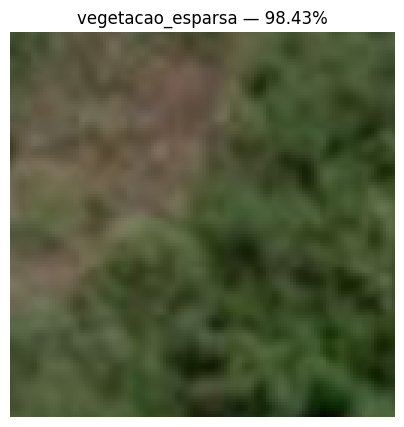

In [11]:
random_image_path = random.choice(all_test_images)
medistar_prediction_report(random_image_path)

## Conclusão da demonstração

A demonstração funcional mostrou que o modelo treinado consegue receber uma nova imagem de satélite, classificar o tipo de território predominante e retornar uma interpretação operacional para o contexto do Medistar.

Essa classificação pode ser utilizada como uma variável auxiliar no cálculo de risco territorial, apoiando decisões sobre priorização de atendimento em comunidades isoladas. Por exemplo, regiões classificadas como vegetação densa ou terreno exposto podem indicar maior dificuldade de deslocamento, enquanto áreas urbanas podem sugerir maior disponibilidade de infraestrutura.